In [2]:
import pandas as pd

orders_url = "https://drive.google.com/file/d/143CzG5DriVSPMkaL1UP4k3Y80oS8fgbV/view?usp=sharing"
orderlines_url = "https://drive.google.com/file/d/1yWO-mQfxQtnSZdCgdNlIEUrZSCW1HN5O/view?usp=sharing"
products_url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
brands_url = "https://drive.google.com/file/d/1XGyabaa4mAkjixMk3XPgx_14OoSse3rs/view?usp=sharing"

def import_csv(url):
  path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
  return pd.read_csv(path)

# Importing csvs and correcting data types
orderlines_qu = import_csv(orderlines_url)
orderlines_qu['date'] = pd.to_datetime(orderlines_qu['date'])
orders_qu = import_csv(orders_url)
orders_qu['created_date'] = pd.to_datetime(orders_qu['created_date'])
products_cl = import_csv(products_url)
brands_df = import_csv(brands_url)

# Incorporating additional information into orderlines data frame
orderlines_qu['short'] = orderlines_qu['sku'].str[:3]
orderlines_expanded = (
    orderlines_qu
    .merge(products_cl,
           on='sku')
    .merge(brands_df,
           on='short')
    .rename(columns={'long':'brand'})
    .drop(columns='short')
)
# Creating composite columns
orderlines_expanded['revenue'] = (
    orderlines_expanded['unit_price'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['discount'] = (
    orderlines_expanded['price'] - orderlines_expanded['unit_price']
)
orderlines_expanded['total_discount'] = (
    orderlines_expanded['discount'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['percentage_discount'] = (
    100 * orderlines_expanded['discount'] / orderlines_expanded['price']
)

#### Exercise 1: Import Seaborn and use a scatterplot to see if revenue and total discount are correlated

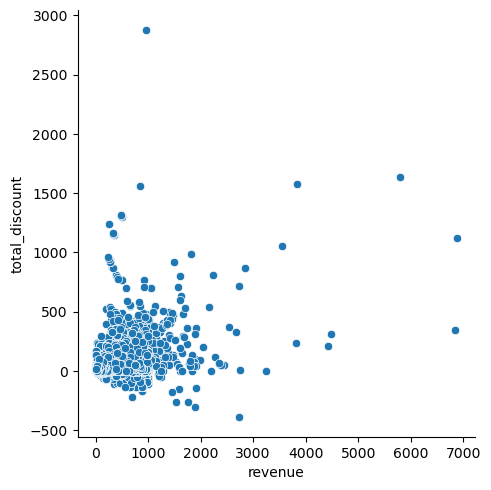

In [4]:
# Your code here
import seaborn as sns

sns.relplot(
           data=orderlines_expanded,
           x='revenue',
           y='total_discount'
);

##### Hint:

No need to do any work in pandas, just jump right into `sns.relplot()`

#### Exercise 2: Use Seaborn to plot the total discounted each month as a line plot

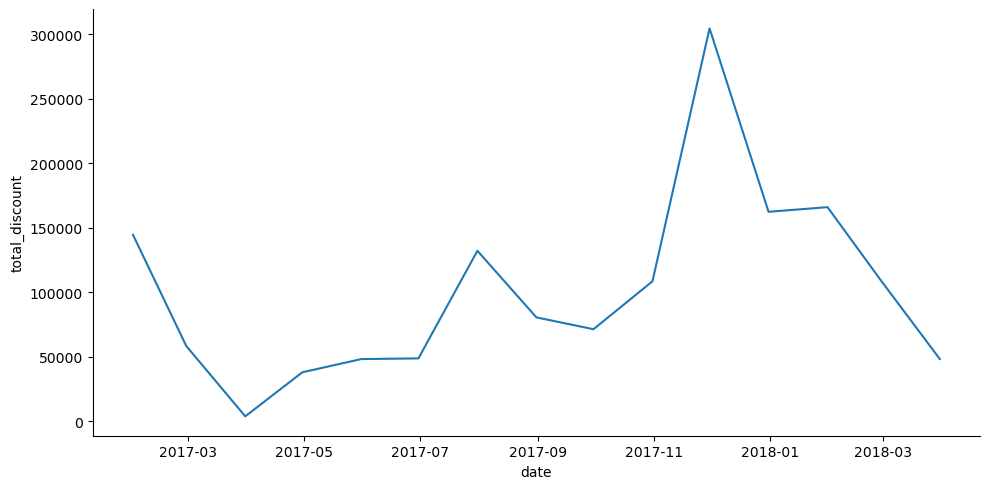

In [5]:
# Your code here
total_discount_plot = (
    orderlines_expanded
    .resample('ME', on='date')
    .agg({'total_discount' : 'sum'})
    .reset_index()
)

sns.relplot(total_discount_plot,
           x='date',
           y='total_discount',
           kind = 'line',
           aspect=2);


##### Hint:

```
monthly_discount = df.resample().agg()
sns._______(data=monthly_discount,
            ...
)

```

#### Exercise 3: Use seaborn to plot a scatterplot visualizing the relationship between the total quantity sold and the average percentage discount for each product<br>
(To simplify this exercise, you don't need to take into account `'product_quantity'` in the average discount percentage)

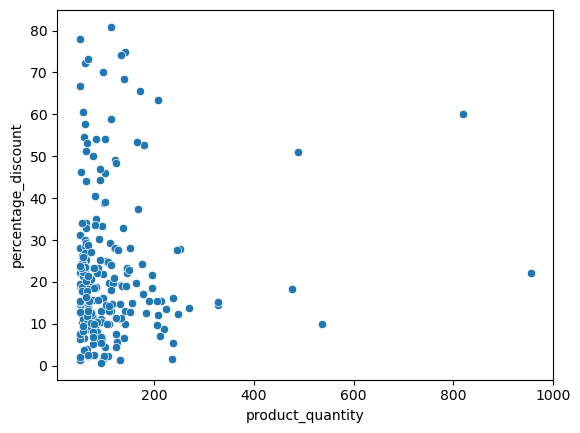

In [11]:
# Your code here
aggs = (
    orderlines_expanded
    .groupby('sku')
    .agg({'product_quantity' : 'sum',
          'percentage_discount': 'mean'})
       )

sns.scatterplot(data=aggs.loc[aggs['product_quantity'] > 50], 
               x='product_quantity',
               y='percentage_discount'
               );

##### Hint:

```
aggs = df.groupby(___).agg({__:__, __:__})
sns._______(data=aggs,
            ...
)

```

#### Exercise 4: Use Seaborn to plot the quantity of iPhone cases sold as a line plot

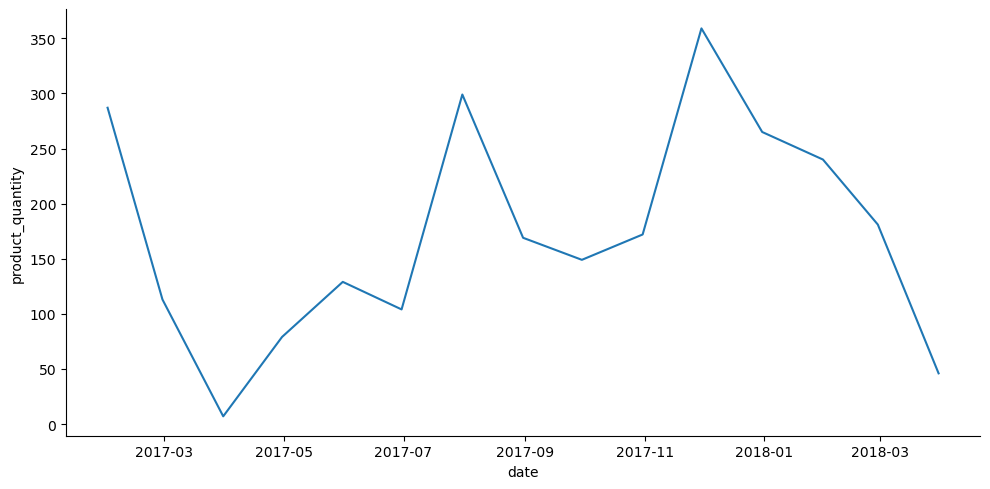

In [17]:
# Your code here
has_iphone = (
    orderlines_expanded['desc']
    .str.contains('iPhone', case=False)
)
has_case = (
    orderlines_expanded['desc']
    .str.contains('case', case=False)
)

orderlines_expanded_df = orderlines_expanded.loc[has_iphone & has_case]
apple_per_month = (
    orderlines_expanded_df
    .resample("ME", on='date')
    .agg({'product_quantity' : 'sum'})
)

sns.relplot(data=apple_per_month,
            kind='line',
            x='date',
            y='product_quantity',
            aspect=2);

##### Hint:

You'll have to use string methods with `.str` to filter the data frame, then `.resample().agg()` to aggregate and then `sns.relplot()` to plot the results

#### Exercise 5: Write a Python function that takes in a data frame and the name of a numerical column and returns a mask that could be used **to select outlier rows**<br>
Hint 1 reminds you what the rule is in statistics for determining if data is an outlier and well as the pandas function necessary to get the required numbers<br>
Hint 2 gives further guidance on how to complete the function

In [19]:
# Your code here
def get_outlier_mask(df, col_name):
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return (df[col_name] < lower_bound) | (df[col_name] > upper_bound) 

orderlines_expanded.loc[get_outlier_mask(orderlines_expanded, 'percentage_discount')]

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,revenue,discount,total_discount,percentage_discount
52,1119666,299815,0,1,LOG0084,18.99,2017-01-01 17:30:57,Logitech Ultrathin Keyboard Cover Keyboard Cov...,Ultrathin cover and cover with Bluetooth keybo...,89.99,0,12575403,Logitech,18.99,71.00,71.00,78.897655
54,1119691,299825,0,1,LOG0084,18.99,2017-01-01 17:44:45,Logitech Ultrathin Keyboard Cover Keyboard Cov...,Ultrathin cover and cover with Bluetooth keybo...,89.99,0,12575403,Logitech,18.99,71.00,71.00,78.897655
72,1119820,299895,0,1,PAR0054,65.55,2017-01-01 19:27:08,Jumping Parrot Drone White Night BUZZ,MiniDrone remote control with LEDs and video t...,159.90,0,11905404,Parrot,65.55,94.35,94.35,59.005629
94,1120018,299991,0,1,LOG0084,18.99,2017-01-01 21:18:11,Logitech Ultrathin Keyboard Cover Keyboard Cov...,Ultrathin cover and cover with Bluetooth keybo...,89.99,0,12575403,Logitech,18.99,71.00,71.00,78.897655
100,1120083,300028,0,1,PAR0053,65.55,2017-01-01 22:00:08,Jumping Parrot Drone Night Blue Diesel,MiniDrone remote control with LEDs and video t...,159.90,0,11905404,Parrot,65.55,94.35,94.35,59.005629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53190,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,9.99,15.01,15.01,60.040000
53191,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,19.98,15.01,30.02,60.040000
53192,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,19.98,15.01,30.02,60.040000
53193,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,Apple,29.97,15.01,45.03,60.040000


In [21]:
def get_bounds(df, col_name):
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return upper_bound, lower_bound
    
def outlier_filter(df, col_name):
    upper_bound, lower_bound = get(df,col_name)
    return (df[col_name] < lower_bound) | (df[col_name] > upper_bound) 

get_bounds(orderlines_expanded, 'percentage_discount')

(57.823757812607596, -20.146155033081925)

##### Hint 1:

The rule for whether data is an outlier is based on the interquartile range. If the data is 1.5 times the interquartile range outside the interquartile range it is considered an outlier. In other words: <br>`q1 - (1.5 * iqr) < not_outlier < q3 + (1.5 * iqr)`<br><br> If you don't remember what the interquartile range is, feel free to Google it.<br><br>
To get the quartiles with pandas, you can use the method `pd.Series.quantile()` For instance: `q1 = df[].quantile(0.25)`

##### Hint 2:

You will have to calculate the 1st and 3rd quartiles, then get the interquartile range, and use it to create two boolean masks. Then combine those masks and return them as one composite mask<br>
```
def outliers_filter(df, num_col):
  q1 = df[num_col].quantile(0.25)
  ...
  return outlier_mask
```

#### Bonus: Use Seaborn to plot the average percentage discount and total number of **orders** daily. Plot them in separate plots, one above the other<br>
To simplify things, don't bother weighting the average percentage discount according to the quantity

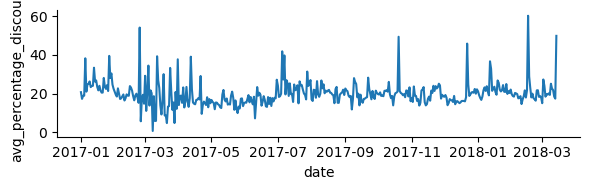

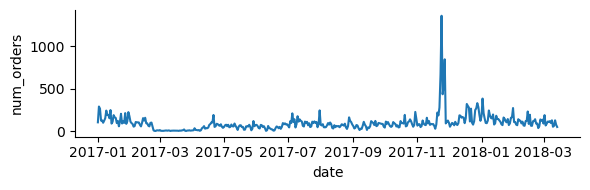

In [7]:
# Your code here
daily_aggs = (
    orderlines_expanded
    .resample('D', on='date')
    .agg(avg_percentage_discount = ('percentage_discount', 'mean'),
         num_orders = ('id_order', 'nunique'))
)

sns.relplot(daily_aggs, 
            x='date', 
            y='avg_percentage_discount', 
            kind='line',
            # height=2,
            aspect=3
           );
sns.relplot(daily_aggs, 
            x='date', 
            y='num_orders', 
            kind='line',
            # height=2,
            aspect=3
           );

##### Hint:

These will need to be separate line plots since we are plotting different variables. You cannot use `col=` or `row=` because these parameters just segment the data, each plot still plots the same variables<br>
```
daily_aggs = df.resample().agg()
sns.relplot(...)
sns.relplot(...)
```

#### Demo: How to overlay two lines with different y axes (this will be shown during solutions)

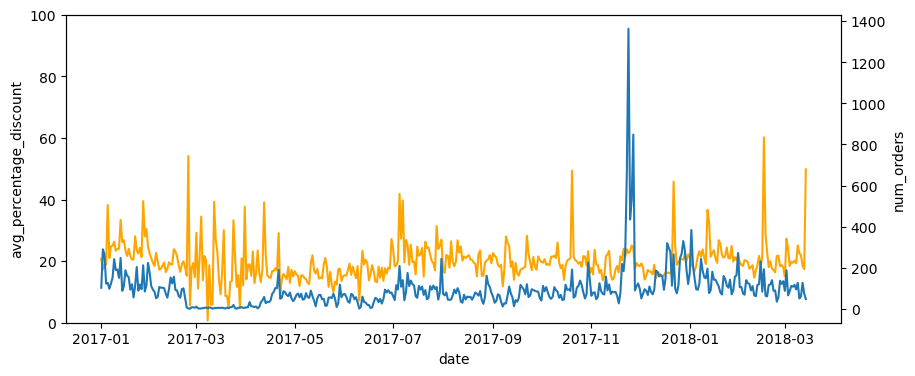

In [13]:
# Instructor's code here
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,4))

sns.lineplot(daily_aggs, 
            x='date', 
            y='avg_percentage_discount',
            color = 'orange',
            ax=ax1);

ax1.set_ylim(0,100)

ax2 = ax1.twinx()

sns.lineplot(daily_aggs, 
            x='date', 
            y='num_orders',
            ax=ax2);